# Ass Chapter 5 - Exercise 8
Cross-validation on a simulated data set.

In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP.models import ModelSpec as MS, summarize
from sklearn.model_selection import cross_validate
from ISLP.models import sklearn_sm

**(a)** Generate the simulated data set.

In [2]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

Here n = 100 (the number of observations) and p = 1 (a single predictor, X). The model used to generate the data, in equation form, is:

Y = X − 2X² + ε

**(b)** Scatterplot of X against Y.

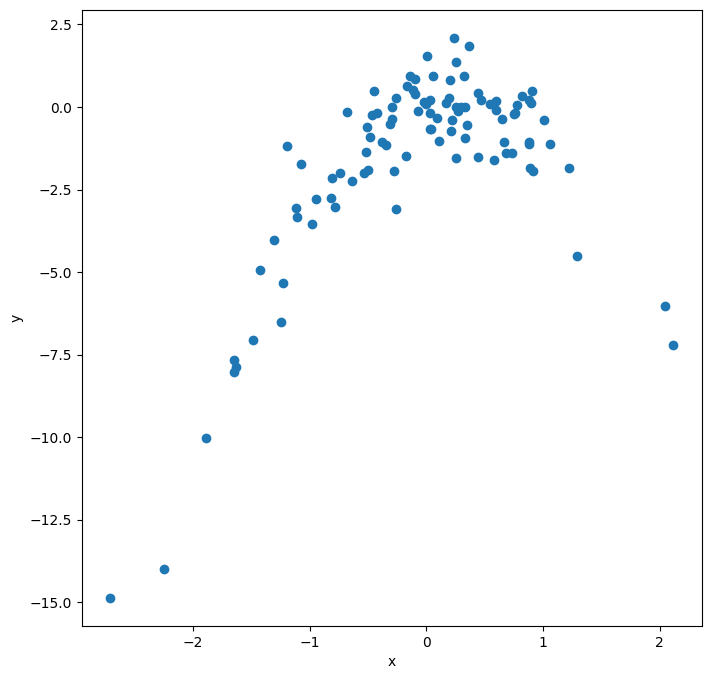

In [3]:
fig, ax = subplots(figsize=(8, 8))
ax.scatter(x, y)
ax.set_xlabel('x')
ax.set_ylabel('y');

*Comment:* the plot shows a clear curved (quadratic, downward-opening) relationship between X and Y, consistent with the Y = X − 2X² + ε model used to generate the data.

**(c)** LOOCV error for four polynomial models, using a fixed random seed.

In [4]:
rng = np.random.default_rng(2)  # seed set before running the CV loop
df = pd.DataFrame({'x': x, 'y': y})
M = sklearn_sm(sm.OLS)
cv_error = np.zeros(4)
for i, d in enumerate(range(1, 5)):
    X_d = np.power.outer(x, np.arange(d + 1))
    M_CV = cross_validate(M, X_d, y, cv=len(x))
    cv_error[i] = np.mean(M_CV['test_score'])
cv_error

array([6.63302984, 1.12293686, 1.30179655, 1.33239427])

**(d)** Repeat (c) with a different random seed.

In [5]:
rng = np.random.default_rng(3)  # different seed
cv_error_seed2 = np.zeros(4)
for i, d in enumerate(range(1, 5)):
    X_d = np.power.outer(x, np.arange(d + 1))
    M_CV = cross_validate(M, X_d, y, cv=len(x))
    cv_error_seed2[i] = np.mean(M_CV['test_score'])
cv_error_seed2

array([6.63302984, 1.12293686, 1.30179655, 1.33239427])

The results are exactly the same as in (c). This is expected: LOOCV has no randomness in how the folds are formed — every single observation is held out exactly once, in a fixed order, regardless of the random seed. The seed would only matter for the validation set approach or k-fold CV, which involve a random split.

**(e)** Which model had the smallest LOOCV error?

In [6]:
cv_error

array([6.63302984, 1.12293686, 1.30179655, 1.33239427])

The quadratic model (degree 2) has the smallest LOOCV error, by a wide margin over the linear model, with little further improvement from degrees 3 and 4. This matches expectations, since the data were generated from a true quadratic relationship (Y = X − 2X² + ε) — the linear model underfits, and the cubic/quartic terms add unnecessary flexibility without reducing error further.

**(f)** Statistical significance of the coefficients in each model.

In [7]:
# build each polynomial design matrix directly and fit with sm.OLS for p-values
for d in range(1, 5):
    X_d = sm.add_constant(np.power.outer(x, np.arange(1, d + 1)))
    results = sm.OLS(y, X_d).fit()
    print(f'--- degree {d} ---')
    print(summarize(results))

--- degree 1 ---
         coef  std err      t  P>|t|
const -1.4650    0.247 -5.937    0.0
x1     1.9494    0.289  6.752    0.0
--- degree 2 ---
         coef  std err       t  P>|t|
const -0.0728    0.119  -0.611  0.543
x1     0.9663    0.126   7.647  0.000
x2    -2.0047    0.091 -22.072  0.000
--- degree 3 ---
         coef  std err       t  P>|t|
const -0.0572    0.120  -0.477  0.635
x1     1.1146    0.187   5.945  0.000
x2    -2.0471    0.099 -20.673  0.000
x3    -0.0643    0.060  -1.070  0.287
--- degree 4 ---
         coef  std err       t  P>|t|
const  0.1008    0.136   0.743  0.460
x1     0.9050    0.205   4.423  0.000
x2    -2.5059    0.221 -11.336  0.000
x3     0.0338    0.073   0.466  0.642
x4     0.1042    0.045   2.309  0.023


Across all four models, the linear (x¹) and quadratic (x²) terms are highly statistically significant. The cubic term (x³) is never significant, and the quartic term (x⁴) is only borderline significant in the degree-4 model (p ≈ 0.02) — far weaker than x¹ and x². This agrees closely with the LOOCV results in (e): both approaches point to the quadratic model as essentially the best fit, with the higher-order terms adding little to no real value.